# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


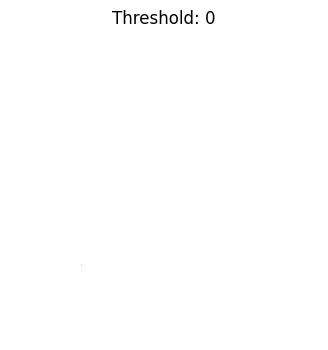

Threshold value: 50


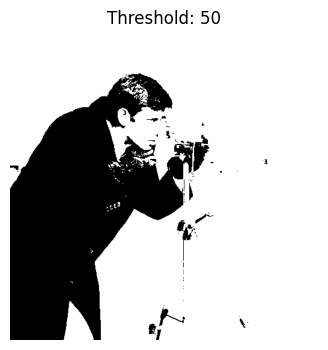

Threshold value: 100


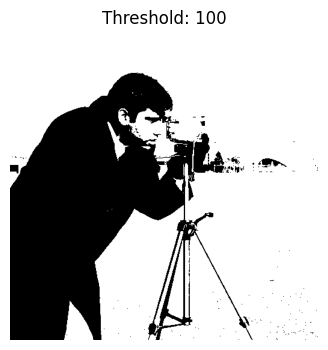

Threshold value: 150


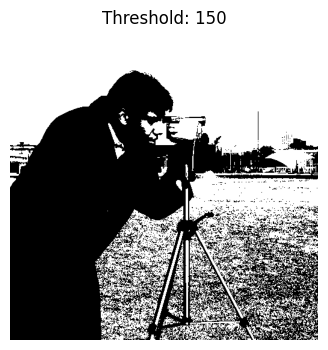

Threshold value: 200


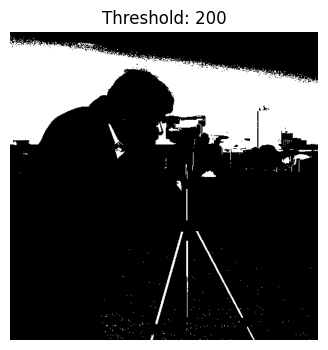

In [3]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

# Load the cameraman image directly from skimage (no file needed)
img = data.camera()

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values and display using matplotlib
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f"Threshold value: {threshold_value}")
    plt.figure(figsize=(4, 4))
    plt.imshow(thresh_img, cmap='gray')
    plt.title(f"Threshold: {threshold_value}")
    plt.axis('off')
    plt.show()

Original Image: 


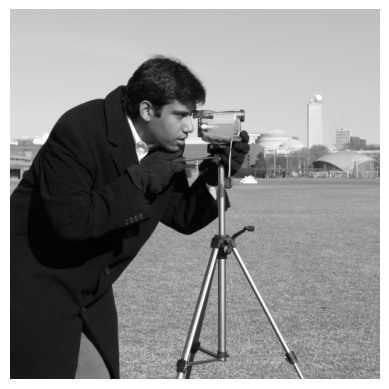

In [6]:
print("Original Image: ")
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

## Histograms

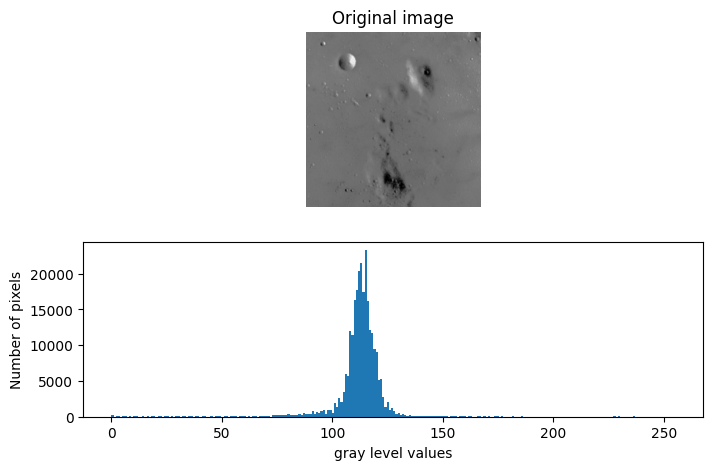

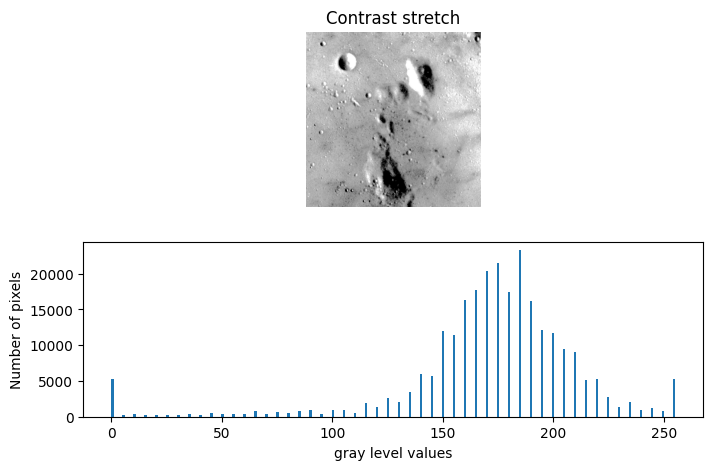

In [7]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram



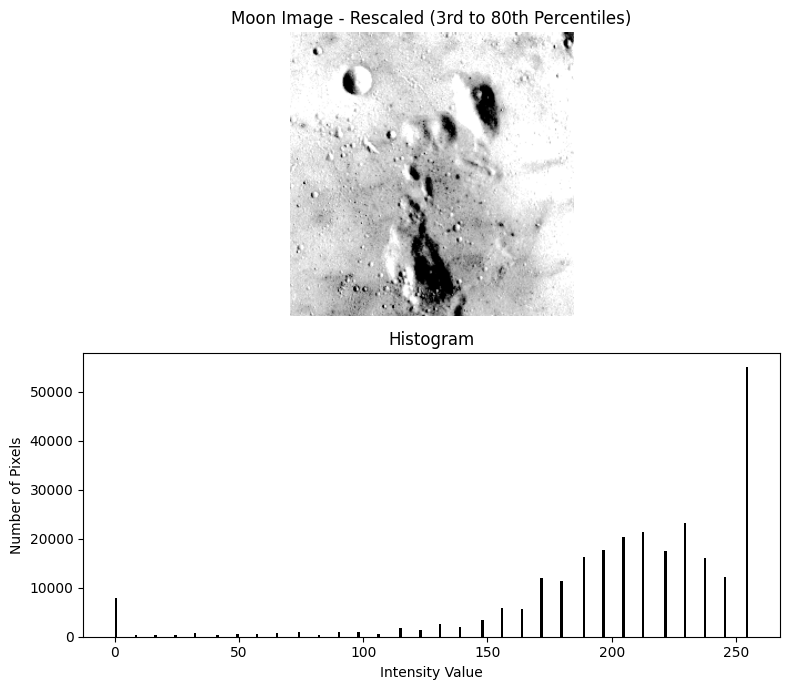

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data
from skimage import exposure

# Load moon image
img = data.moon()

# Compute 3rd and 80th percentiles
p3, p80 = np.percentile(img, (3, 80))

# Rescale intensity values
img_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))

# Display the rescaled image and histogram cleanly
plt.figure(figsize=(8, 7))

plt.subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.title('Moon Image - Rescaled (3rd to 80th Percentiles)')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.hist(img_rescale.ravel(), bins=256, range=(0, 255), color='black')
plt.xlabel('Intensity Value')
plt.ylabel('Number of Pixels')
plt.title('Histogram')

plt.tight_layout()
plt.show()

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.


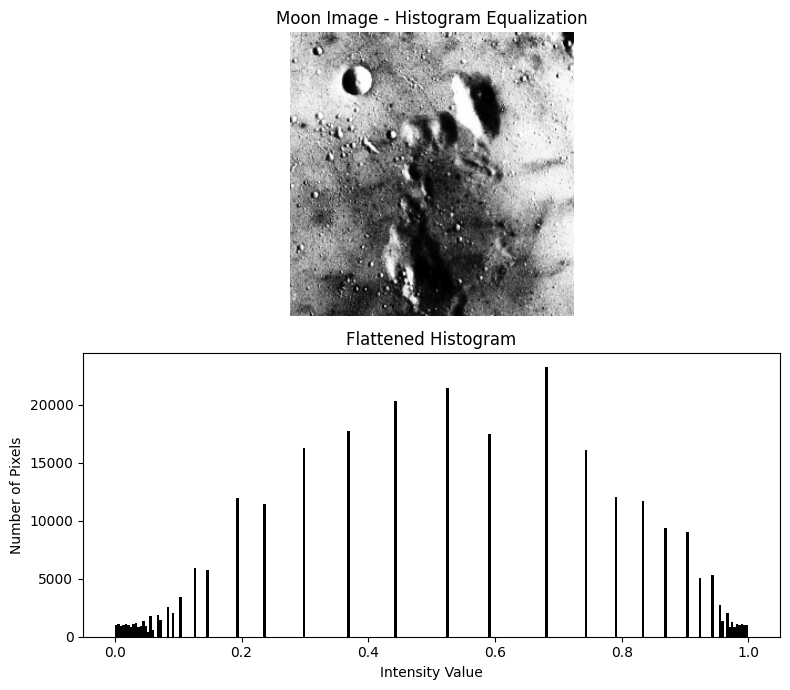

In [13]:
# Step 1: Apply histogram equalization
img_eq = exposure.equalize_hist(img)

# Step 2: Display the equalized image and its flattened histogram
fig = plt.figure(figsize=(8, 7))

# Subplot 1: Equalized Image
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.title('Moon Image - Histogram Equalization')
plt.axis('off')

# Subplot 2: Histogram of Equalized Image
fig.add_subplot(2, 1, 2)
plt.hist(img_eq.ravel(), bins=256, range=(0, 1), color='black')
plt.xlabel('Intensity Value')
plt.ylabel('Number of Pixels')
plt.title('Flattened Histogram')

plt.tight_layout()
plt.show()

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching

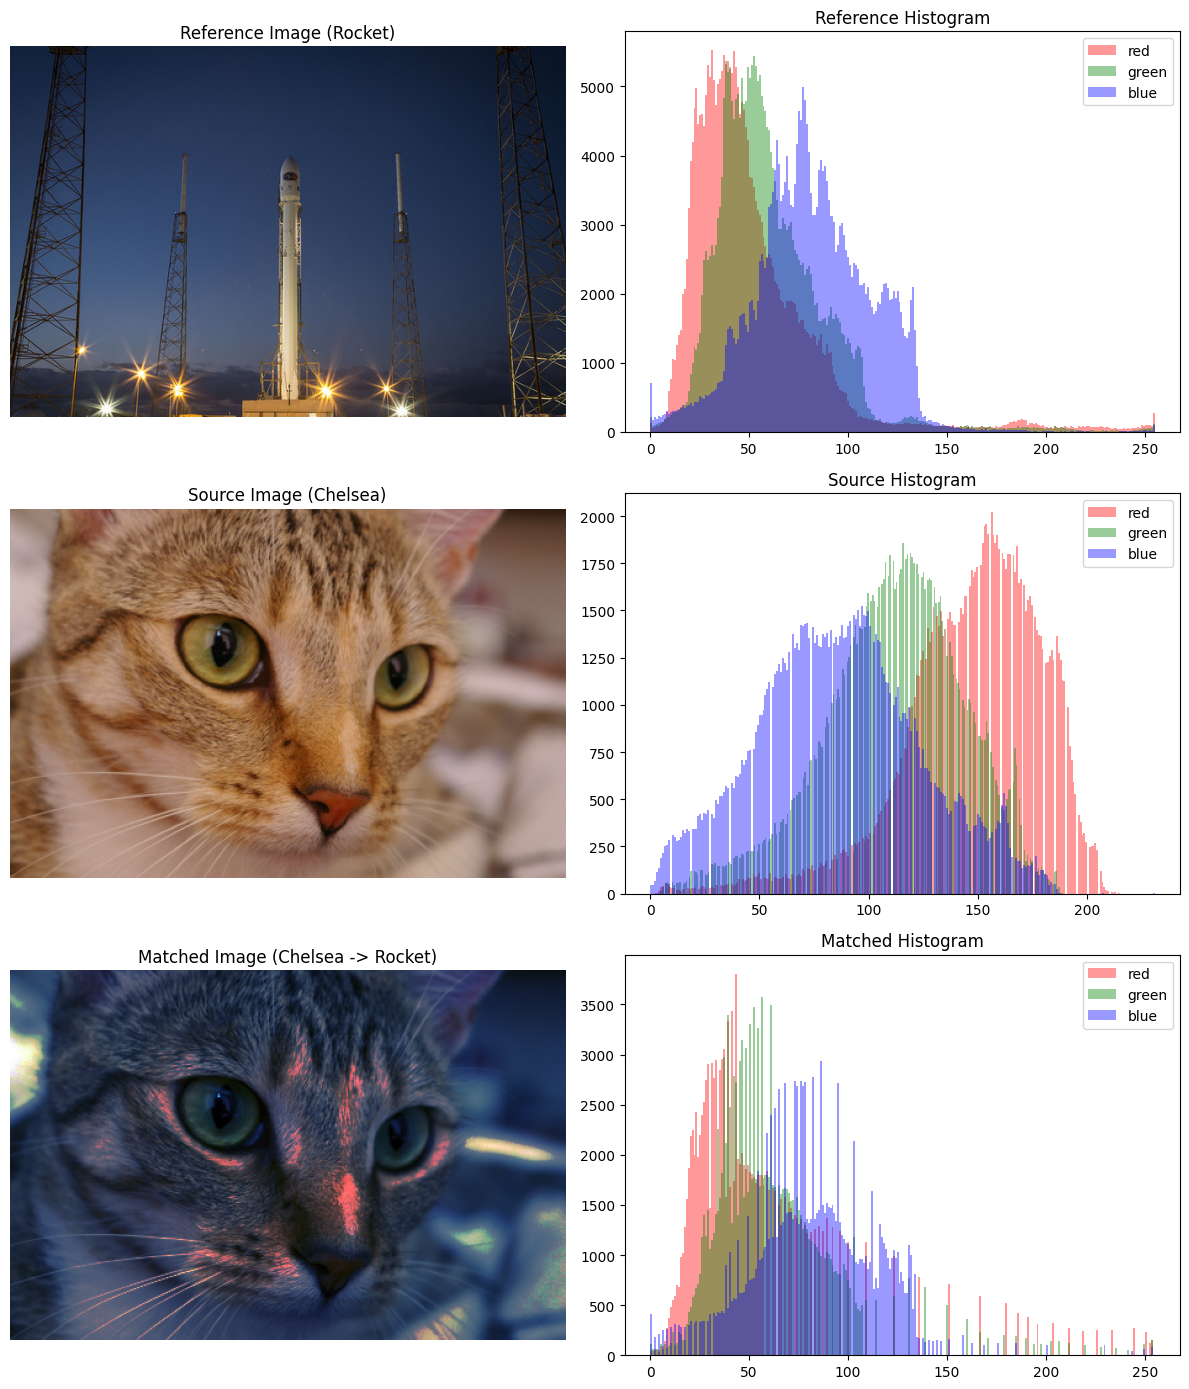

In [16]:
from skimage import data, img_as_ubyte
from skimage.exposure import match_histograms
import matplotlib.pyplot as plt

# Step 1: Load reference (rocket) and source (chelsea) images
reference = data.rocket()
image = data.chelsea()

# Step 2: Perform histogram matching across all color channels
matched_image = match_histograms(image, reference, channel_axis=-1)
matched_ubyte = img_as_ubyte(matched_image)  # Prevents color clipping

# Step 3: Plot using sequential plt.subplot() calls instead of axes[row, col]
plt.figure(figsize=(12, 14))

# --- Row 1: Reference (Rocket) ---
plt.subplot(3, 2, 1)
plt.imshow(reference)
plt.title('Reference Image (Rocket)')
plt.axis('off')

plt.subplot(3, 2, 2)
for i, color in enumerate(['red', 'green', 'blue']):
    plt.hist(reference[:, :, i].ravel(), bins=256, color=color, alpha=0.4, label=color)
plt.title('Reference Histogram')
plt.legend()

# --- Row 2: Source (Chelsea) ---
plt.subplot(3, 2, 3)
plt.imshow(image)
plt.title('Source Image (Chelsea)')
plt.axis('off')

plt.subplot(3, 2, 4)
for i, color in enumerate(['red', 'green', 'blue']):
    plt.hist(image[:, :, i].ravel(), bins=256, color=color, alpha=0.4, label=color)
plt.title('Source Histogram')
plt.legend()

# --- Row 3: Matched Image ---
plt.subplot(3, 2, 5)
plt.imshow(matched_ubyte)
plt.title('Matched Image (Chelsea -> Rocket)')
plt.axis('off')

plt.subplot(3, 2, 6)
for i, color in enumerate(['red', 'green', 'blue']):
    plt.hist(matched_image[:, :, i].ravel(), bins=256, color=color, alpha=0.4, label=color)
plt.title('Matched Histogram')
plt.legend()

plt.tight_layout()
plt.show()